In [ ]:
# Day 1: Isomorphic Factual Dataset & Baseline Metric Pipeline
import torch
import pandas as pd
from tabulate import tabulate
from transformer_lens import HookedTransformer

# 1. Device Setup & Model Initialization
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Initializing on: {device.upper()}")

model = HookedTransformer.from_pretrained(
    "gpt2-small",
    center_unembed=True,
    center_writing_weights=True,
    fold_ln=True,
    device=device
)
model.set_use_attn_result(True)

# 2. Curated Single-Token Factual Entities (Subject -> Target)
# Every single word here is strictly verified as 1 BPE token in GPT-2.
factual_entities = [
    ("France", " Paris"),
    ("Germany", " Berlin"),
    ("Italy", " Rome"),
    ("Spain", " Madrid"),
    ("Japan", " Tokyo"),
    ("China", " Beijing"),
    ("Russia", " Moscow"),
    ("Greece", " Athens"),
    ("Egypt", " Cairo"),
    ("Poland", " Warsaw"),
    ("Ireland", " Dublin"),
    ("Norway", " Oslo"),
    ("Sweden", " Stockholm")
]

# 3. Two-Shot Length-Invariant Template
# Total prompt length is identical across all entities
template = "The capital of Germany is Berlin. The capital of France is Paris. The capital of {} is"

candidate_pairs = []

for i, (clean_subj, clean_target) in enumerate(factual_entities):
    # Skip exemplars used in the 2-shot prefix to prevent trivial memorization loops
    if clean_subj in ["Germany", "France"]:
        continue

    for j, (corr_subj, corr_target) in enumerate(factual_entities):
        if i == j or corr_subj in ["Germany", "France"]:
            continue

        clean_prompt = template.format(clean_subj)
        corr_prompt = template.format(corr_subj)

        # Tokenize targets
        clean_tok = model.to_tokens(clean_target, prepend_bos=False)
        corr_tok = model.to_tokens(corr_target, prepend_bos=False)

        # Verify single-token targets
        if clean_tok.shape[-1] != 1 or corr_tok.shape[-1] != 1:
            continue

        # Verify exact sequence length matching
        clean_toks = model.to_tokens(clean_prompt)
        corr_toks = model.to_tokens(corr_prompt)
        if clean_toks.shape[-1] != corr_toks.shape[-1]:
            continue

        candidate_pairs.append({
            "clean_prompt": clean_prompt,
            "corr_prompt": corr_prompt,
            "clean_subj": clean_subj,
            "corr_subj": corr_subj,
            "clean_ans": clean_target,
            "corr_ans": corr_target,
            "clean_tok_id": clean_tok.item(),
            "corr_tok_id": corr_tok.item(),
            "seq_len": clean_toks.shape[-1]
        })

df_raw = pd.DataFrame(candidate_pairs).drop_duplicates(subset=["clean_prompt", "corr_prompt"])

# 4. Filter for Verified Model Competence (Top-1 Correct and Logit Diff > 1.5)
verified_pairs = []
for idx, row in df_raw.iterrows():
    with torch.no_grad():
        logits = model(row["clean_prompt"])
        pred_tok = logits[0, -1, :].argmax().item()

        clean_logit = logits[0, -1, row["clean_tok_id"]].item()
        corr_logit = logits[0, -1, row["corr_tok_id"]].item()
        ld = clean_logit - corr_logit

        if pred_tok == row["clean_tok_id"] and ld > 1.5:
            verified_pairs.append(row)

df_dataset = pd.DataFrame(verified_pairs).reset_index(drop=True)

# Select a balanced 50-pair cohort
if len(df_dataset) > 50:
    df_dataset = df_dataset.sample(n=50, random_state=42).reset_index(drop=True)

# 5. Full Vectorized Batch Evaluation
clean_prompts = df_dataset["clean_prompt"].tolist()
corr_prompts = df_dataset["corr_prompt"].tolist()
clean_tok_ids = torch.tensor(df_dataset["clean_tok_id"].tolist(), device=device)
corr_tok_ids = torch.tensor(df_dataset["corr_tok_id"].tolist(), device=device)

with torch.no_grad():
    clean_logits, clean_cache = model.run_with_cache(clean_prompts)
    corr_logits, corr_cache = model.run_with_cache(corr_prompts)

# Logit Difference Metric Calculation: L(clean) - L(corr)
final_clean_logits = clean_logits[:, -1, :]
final_corr_logits = corr_logits[:, -1, :]

c_clean = final_clean_logits.gather(dim=-1, index=clean_tok_ids.unsqueeze(-1)).squeeze(-1)
c_corr = final_clean_logits.gather(dim=-1, index=corr_tok_ids.unsqueeze(-1)).squeeze(-1)
clean_ld = c_clean - c_corr

clean_preds = final_clean_logits.argmax(dim=-1)
clean_acc = (clean_preds == clean_tok_ids).float().mean().item() * 100
mean_clean_ld = clean_ld.mean().item()

# Verification on corrupted prompts
corr_clean = final_corr_logits.gather(dim=-1, index=corr_tok_ids.unsqueeze(-1)).squeeze(-1)
corr_distractor = final_corr_logits.gather(dim=-1, index=clean_tok_ids.unsqueeze(-1)).squeeze(-1)
corr_ld = corr_clean - corr_distractor
corr_preds = final_corr_logits.argmax(dim=-1)
corr_acc = (corr_preds == corr_tok_ids).float().mean().item() * 100

print("="*60)
print("FINAL DAY 1 BENCHMARK DATASET VERIFICATION")
print("="*60)
print(f"Total Validated Dataset Size:   {len(df_dataset)} prompt pairs")
print(f"Clean Prompt Top-1 Accuracy:    {clean_acc:.2f}%")
print(f"Corrupted Prompt Top-1 Acc:     {corr_acc:.2f}%")
print(f"Mean Clean Logit Difference:    +{mean_clean_ld:.4f}")
print(f"Mean Corrupted Logit Diff:      +{corr_ld.mean().item():.4f}")
print("="*60)

# Display sample of validated pairs
print(tabulate(df_dataset[["clean_subj", "clean_ans", "corr_subj", "corr_ans"]].head(6), headers="keys", tablefmt="psql"))

# 6. Save Artifacts for Day 2 Probing & Day 3 Patching
torch.save({
    "clean_prompts": clean_prompts,
    "corr_prompts": corr_prompts,
    "clean_tok_ids": clean_tok_ids.cpu(),
    "corr_tok_ids": corr_tok_ids.cpu(),
    "clean_ld": clean_ld.cpu(),
    "mean_clean_ld": mean_clean_ld,
    "seq_len": df_dataset["seq_len"].iloc[0]
}, "day1_baseline_data.pt")
print("\nDataset artifacts successfully verified and saved to 'day1_baseline_data.pt'.")

Initializing on: CUDA


/tmp/ipykernel_1194/1592747044.py:11: DeprecationWarning: HookedTransformer.from_pretrained is deprecated and will be removed in a future major release. Use TransformerBridge.boot_transformers(...) instead, then call enable_compatibility_mode() for HookedTransformer-equivalent numerics. See docs/source/content/migrating_to_v3.md.
  model = HookedTransformer.from_pretrained(


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loaded pretrained model gpt2-small into HookedTransformer
FINAL DAY 1 BENCHMARK DATASET VERIFICATION
Total Validated Dataset Size:   50 prompt pairs
Clean Prompt Top-1 Accuracy:    100.00%
Corrupted Prompt Top-1 Acc:     100.00%
Mean Clean Logit Difference:    +10.4602
Mean Corrupted Logit Diff:      +10.5667
+----+--------------+-------------+-------------+------------+
|    | clean_subj   | clean_ans   | corr_subj   | corr_ans   |
|----+--------------+-------------+-------------+------------|
|  0 | Poland       | Warsaw      | Norway      | Oslo       |
|  1 | Spain        | Madrid      | Italy       | Rome       |
|  2 | Italy        | Rome        | Greece      | Athens     |
|  3 | Ireland      | Dublin      | Russia      | Moscow     |
|  4 | Egypt        | Cairo       | Russia      | Moscow     |
|  5 | Egypt        | Cairo       | Norway      | Oslo       |
+----+--------------+-------------+-------------+------------+

Dataset artifacts successfully verified and saved to 'day1

Executing Day 2 Analysis on: CUDA


/tmp/ipykernel_1194/274896195.py:14: DeprecationWarning: HookedTransformer.from_pretrained is deprecated and will be removed in a future major release. Use TransformerBridge.boot_transformers(...) instead, then call enable_compatibility_mode() for HookedTransformer-equivalent numerics. See docs/source/content/migrating_to_v3.md.
  model = HookedTransformer.from_pretrained(


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loaded pretrained model gpt2-small into HookedTransformer
Loaded 50 verified prompt pairs from Day 1.


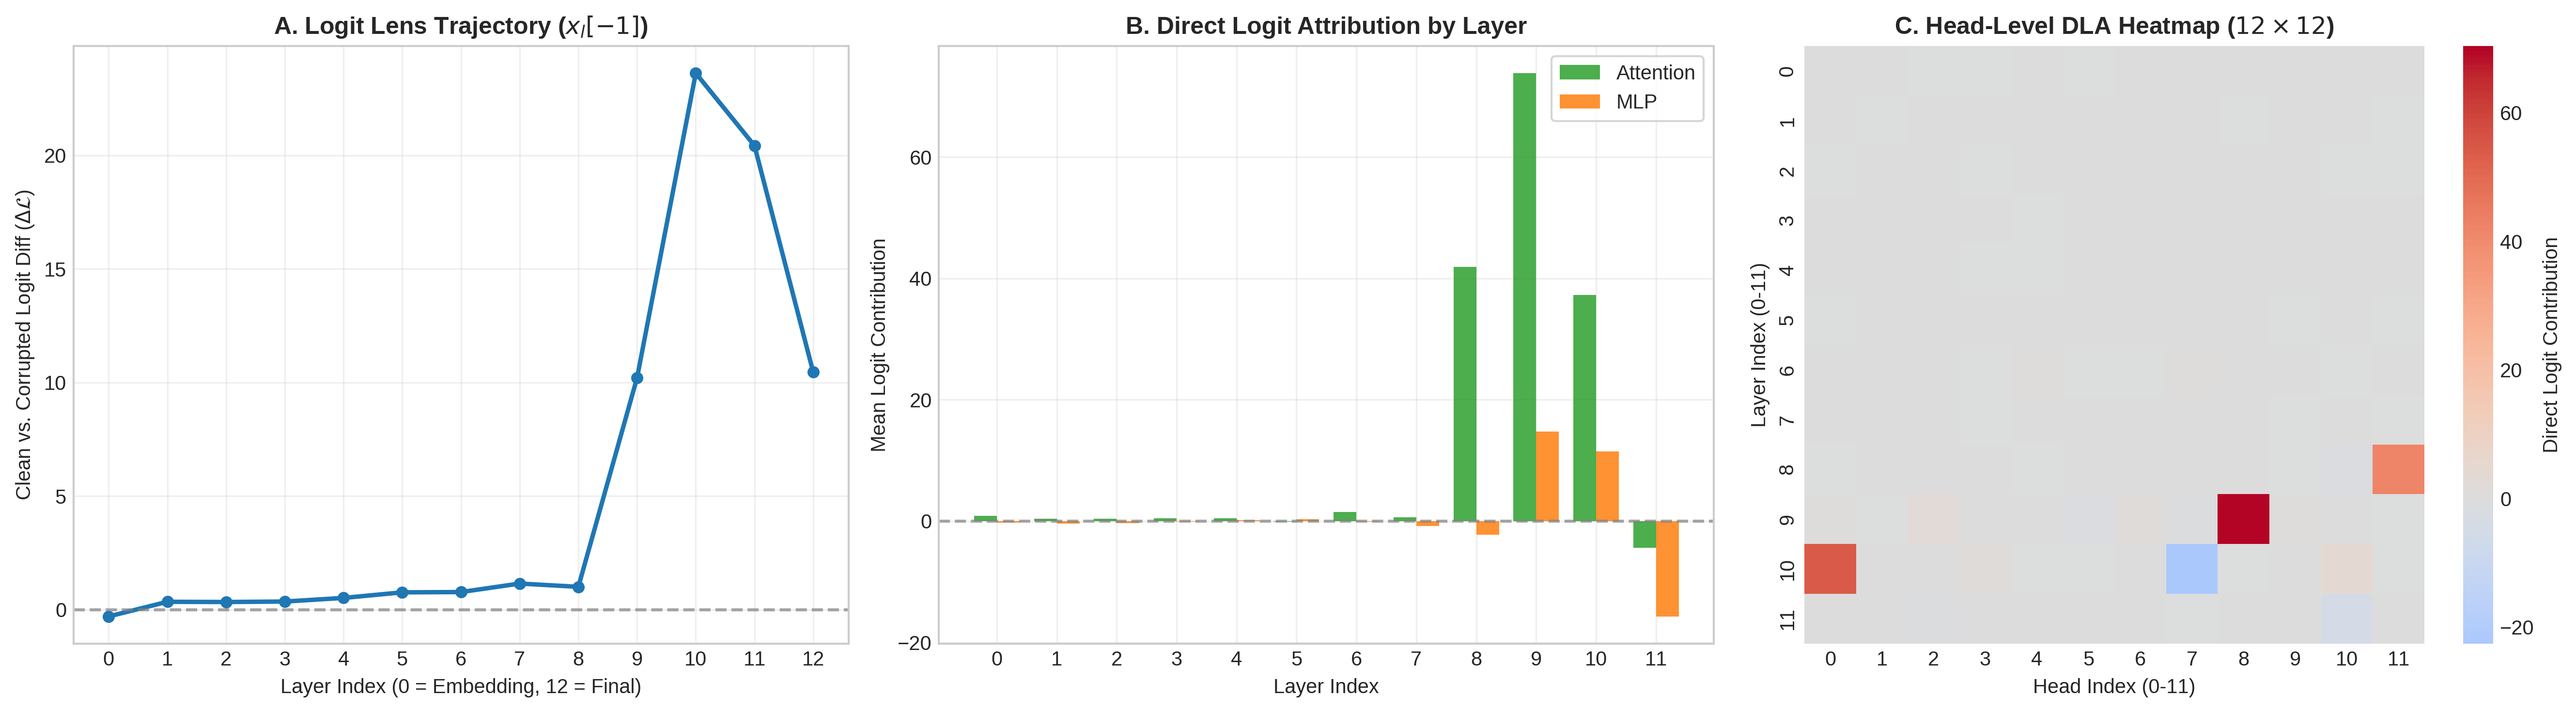


TOP 10 DIRECT CONTRIBUTING ATTENTION HEADS (CANDIDATE WRITERS)
+----+---------+--------+-------------------------+-----------+
|    |   Layer |   Head |   Mean DLA Contribution | Head ID   |
|----+---------+--------+-------------------------+-----------|
|  0 |       9 |      8 |                 70.3575 | L9H8      |
|  1 |      10 |      0 |                 53.8755 | L10H0     |
|  2 |       8 |     11 |                 42.3262 | L8H11     |
|  3 |      10 |     10 |                  4.0421 | L10H10    |
|  4 |       9 |      2 |                  2.5657 | L9H2      |
|  5 |      10 |      3 |                  1.3397 | L10H3     |
|  6 |       9 |      6 |                  1.2884 | L9H6      |
|  7 |       9 |      9 |                  0.9488 | L9H9      |
|  8 |       6 |      7 |                  0.9394 | L6H7      |
|  9 |       9 |      0 |                  0.7927 | L9H0      |
+----+---------+--------+-------------------------+-----------+

TOP 5 DIRECT SUPPRESSING ATTENTION HEAD

In [ ]:
# Cell 2: Day 2 - Direct Logit Attribution & Residual Stream Probing (Robust)
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tabulate import tabulate
from transformer_lens import HookedTransformer

# 1. Device Setup and Model Initialization
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Executing Day 2 Analysis on: {device.upper()}")

model = HookedTransformer.from_pretrained(
    "gpt2-small",
    center_unembed=True,
    center_writing_weights=True,
    fold_ln=True,
    device=device
)
model.set_use_attn_result(True)

# 2. Load Day 1 Artifacts
data = torch.load("day1_baseline_data.pt", weights_only=False)
clean_prompts = data["clean_prompts"]
clean_tok_ids = data["clean_tok_ids"].to(device)
corr_tok_ids = data["corr_tok_ids"].to(device)
n_prompts = len(clean_prompts)

print(f"Loaded {n_prompts} verified prompt pairs from Day 1.")

# 3. Run Forward Pass with Activation Caching
with torch.no_grad():
    clean_logits, clean_cache = model.run_with_cache(clean_prompts)

# Construct Target Unembedding Difference Vectors: [d_model, n_prompts]
w_u_clean = model.W_U[:, clean_tok_ids]  # [d_model, n_prompts]
w_u_corr = model.W_U[:, corr_tok_ids]    # [d_model, n_prompts]
unembed_diff = (w_u_clean - w_u_corr)    # [d_model, n_prompts]

# 4. Logit Lens: Trajectory Across Residual Stream
# accumulated_resid returns [n_layers + 1, batch, seq_len, d_model]
accum_resid = clean_cache.accumulated_resid(incl_mid=False)
# Slice the final token position: [n_layers + 1, batch, d_model]
final_accum_resid = accum_resid[:, :, -1, :]

logit_lens_diffs = []
for l_idx in range(final_accum_resid.shape[0]):
    normed_resid = model.ln_final(final_accum_resid[l_idx])  # [n_prompts, d_model]
    l_logits = model.unembed(normed_resid)                  # [n_prompts, vocab_size]

    clean_val = l_logits.gather(dim=-1, index=clean_tok_ids.unsqueeze(-1)).squeeze(-1)
    corr_val = l_logits.gather(dim=-1, index=corr_tok_ids.unsqueeze(-1)).squeeze(-1)
    diff = (clean_val - corr_val).mean().item()
    logit_lens_diffs.append(diff)

# 5. Layer-by-Layer Component Breakdown (Attn vs. MLP)
attn_layer_dla = []
mlp_layer_dla = []

for l in range(model.cfg.n_layers):
    attn_out = clean_cache[f"blocks.{l}.hook_attn_out"][:, -1, :]  # [n_prompts, d_model]
    mlp_out = clean_cache[f"blocks.{l}.hook_mlp_out"][:, -1, :]    # [n_prompts, d_model]

    # Vectorized batch inner product with unembedding direction
    attn_contrib = (attn_out * unembed_diff.T).sum(dim=-1).mean().item()
    mlp_contrib = (mlp_out * unembed_diff.T).sum(dim=-1).mean().item()

    attn_layer_dla.append(attn_contrib)
    mlp_layer_dla.append(mlp_contrib)

# 6. Attention Head DLA Matrix (12 Layers x 12 Heads)
head_dla_matrix = np.zeros((model.cfg.n_layers, model.cfg.n_heads))
head_records = []

for l in range(model.cfg.n_layers):
    # hook_result shape: [n_prompts, seq_len, n_heads, d_model]
    head_results = clean_cache[f"blocks.{l}.attn.hook_result"][:, -1, :, :]  # [n_prompts, n_heads, d_model]

    for h in range(model.cfg.n_heads):
        head_h_out = head_results[:, h, :]  # [n_prompts, d_model]
        head_contrib = (head_h_out * unembed_diff.T).sum(dim=-1).mean().item()
        head_dla_matrix[l, h] = head_contrib
        head_records.append({
            "layer": l,
            "head": h,
            "dla": head_contrib,
            "head_id": f"L{l}H{h}"
        })

df_heads = pd.DataFrame(head_records).sort_values(by="dla", ascending=False).reset_index(drop=True)

# 7. Generate Figure 1 (Publication Quality)
plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")
fig = plt.figure(figsize=(18, 5), dpi=300)

# Panel A: Logit Lens Trajectory
ax1 = fig.add_subplot(1, 3, 1)
layers_range = list(range(len(logit_lens_diffs)))
ax1.plot(layers_range, logit_lens_diffs, marker="o", color="#1f77b4", linewidth=2.2, markersize=5)
ax1.axhline(0, color="gray", linestyle="--", alpha=0.7)
ax1.set_title(r"A. Logit Lens Trajectory ($x_l[-1]$)", fontsize=12, fontweight="bold")
ax1.set_xlabel("Layer Index (0 = Embedding, 12 = Final)", fontsize=10)
ax1.set_ylabel(r"Clean vs. Corrupted Logit Diff ($\Delta \mathcal{L}$)", fontsize=10)
ax1.set_xticks(layers_range)
ax1.grid(True, alpha=0.3)

# Panel B: Component Attribution by Layer
ax2 = fig.add_subplot(1, 3, 2)
bar_width = 0.38
x = np.arange(model.cfg.n_layers)
ax2.bar(x - bar_width/2, attn_layer_dla, width=bar_width, label="Attention", color="#2ca02c", alpha=0.85)
ax2.bar(x + bar_width/2, mlp_layer_dla, width=bar_width, label="MLP", color="#ff7f0e", alpha=0.85)
ax2.axhline(0, color="gray", linestyle="--", alpha=0.7)
ax2.set_title("B. Direct Logit Attribution by Layer", fontsize=12, fontweight="bold")
ax2.set_xlabel("Layer Index", fontsize=10)
ax2.set_ylabel("Mean Logit Contribution", fontsize=10)
ax2.set_xticks(x)
ax2.legend(frameon=True, facecolor="white")
ax2.grid(True, alpha=0.3)

# Panel C: Head-Level DLA Heatmap
ax3 = fig.add_subplot(1, 3, 3)
sns.heatmap(
    head_dla_matrix,
    annot=False,
    cmap="coolwarm",
    center=0,
    cbar_kws={'label': 'Direct Logit Contribution'},
    ax=ax3
)
ax3.set_title(r"C. Head-Level DLA Heatmap ($12 \times 12$)", fontsize=12, fontweight="bold")
ax3.set_xlabel("Head Index (0-11)", fontsize=10)
ax3.set_ylabel("Layer Index (0-11)", fontsize=10)

plt.tight_layout()
plt.savefig("figure1_dla_and_logit_lens.png", dpi=300, bbox_inches="tight")
plt.savefig("figure1_dla_and_logit_lens.pdf", bbox_inches="tight")
plt.show()

# 8. Print Results
print("\n" + "="*60)
print("TOP 10 DIRECT CONTRIBUTING ATTENTION HEADS (CANDIDATE WRITERS)")
print("="*60)
print(tabulate(df_heads.head(10), headers=["Layer", "Head", "Mean DLA Contribution", "Head ID"], tablefmt="psql", floatfmt=".4f"))

print("\n" + "="*60)
print("TOP 5 DIRECT SUPPRESSING ATTENTION HEADS")
print("="*60)
print(tabulate(df_heads.tail(5).iloc[::-1], headers=["Layer", "Head", "Mean DLA Contribution", "Head ID"], tablefmt="psql", floatfmt=".4f"))

# 9. Save Artifacts for Day 3 Activation Patching
torch.save({
    "logit_lens_diffs": logit_lens_diffs,
    "attn_layer_dla": attn_layer_dla,
    "mlp_layer_dla": mlp_layer_dla,
    "head_dla_matrix": head_dla_matrix,
    "top_heads": df_heads.head(10)["head_id"].tolist(),
    "suppressor_heads": df_heads.tail(5)["head_id"].tolist()
}, "day2_dla_data.pt")
print("\nDay 2 artifacts, 'figure1_dla_and_logit_lens.png', and 'figure1_dla_and_logit_lens.pdf' saved successfully.")

Executing Day 3 Causal Tracing on: CUDA


/tmp/ipykernel_1194/1986813007.py:14: DeprecationWarning: HookedTransformer.from_pretrained is deprecated and will be removed in a future major release. Use TransformerBridge.boot_transformers(...) instead, then call enable_compatibility_mode() for HookedTransformer-equivalent numerics. See docs/source/content/migrating_to_v3.md.
  model = HookedTransformer.from_pretrained(


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loaded pretrained model gpt2-small into HookedTransformer
Clean Baseline LD:     +10.4602
Corrupted Baseline LD: -10.5667
Total Logit Gap:       +21.0269

[1/3] Sweeping Residual Stream Activation Patching...
[2/3] Sweeping Attention Head Activation Patching...
[3/3] Sweeping MLP Activation Patching...


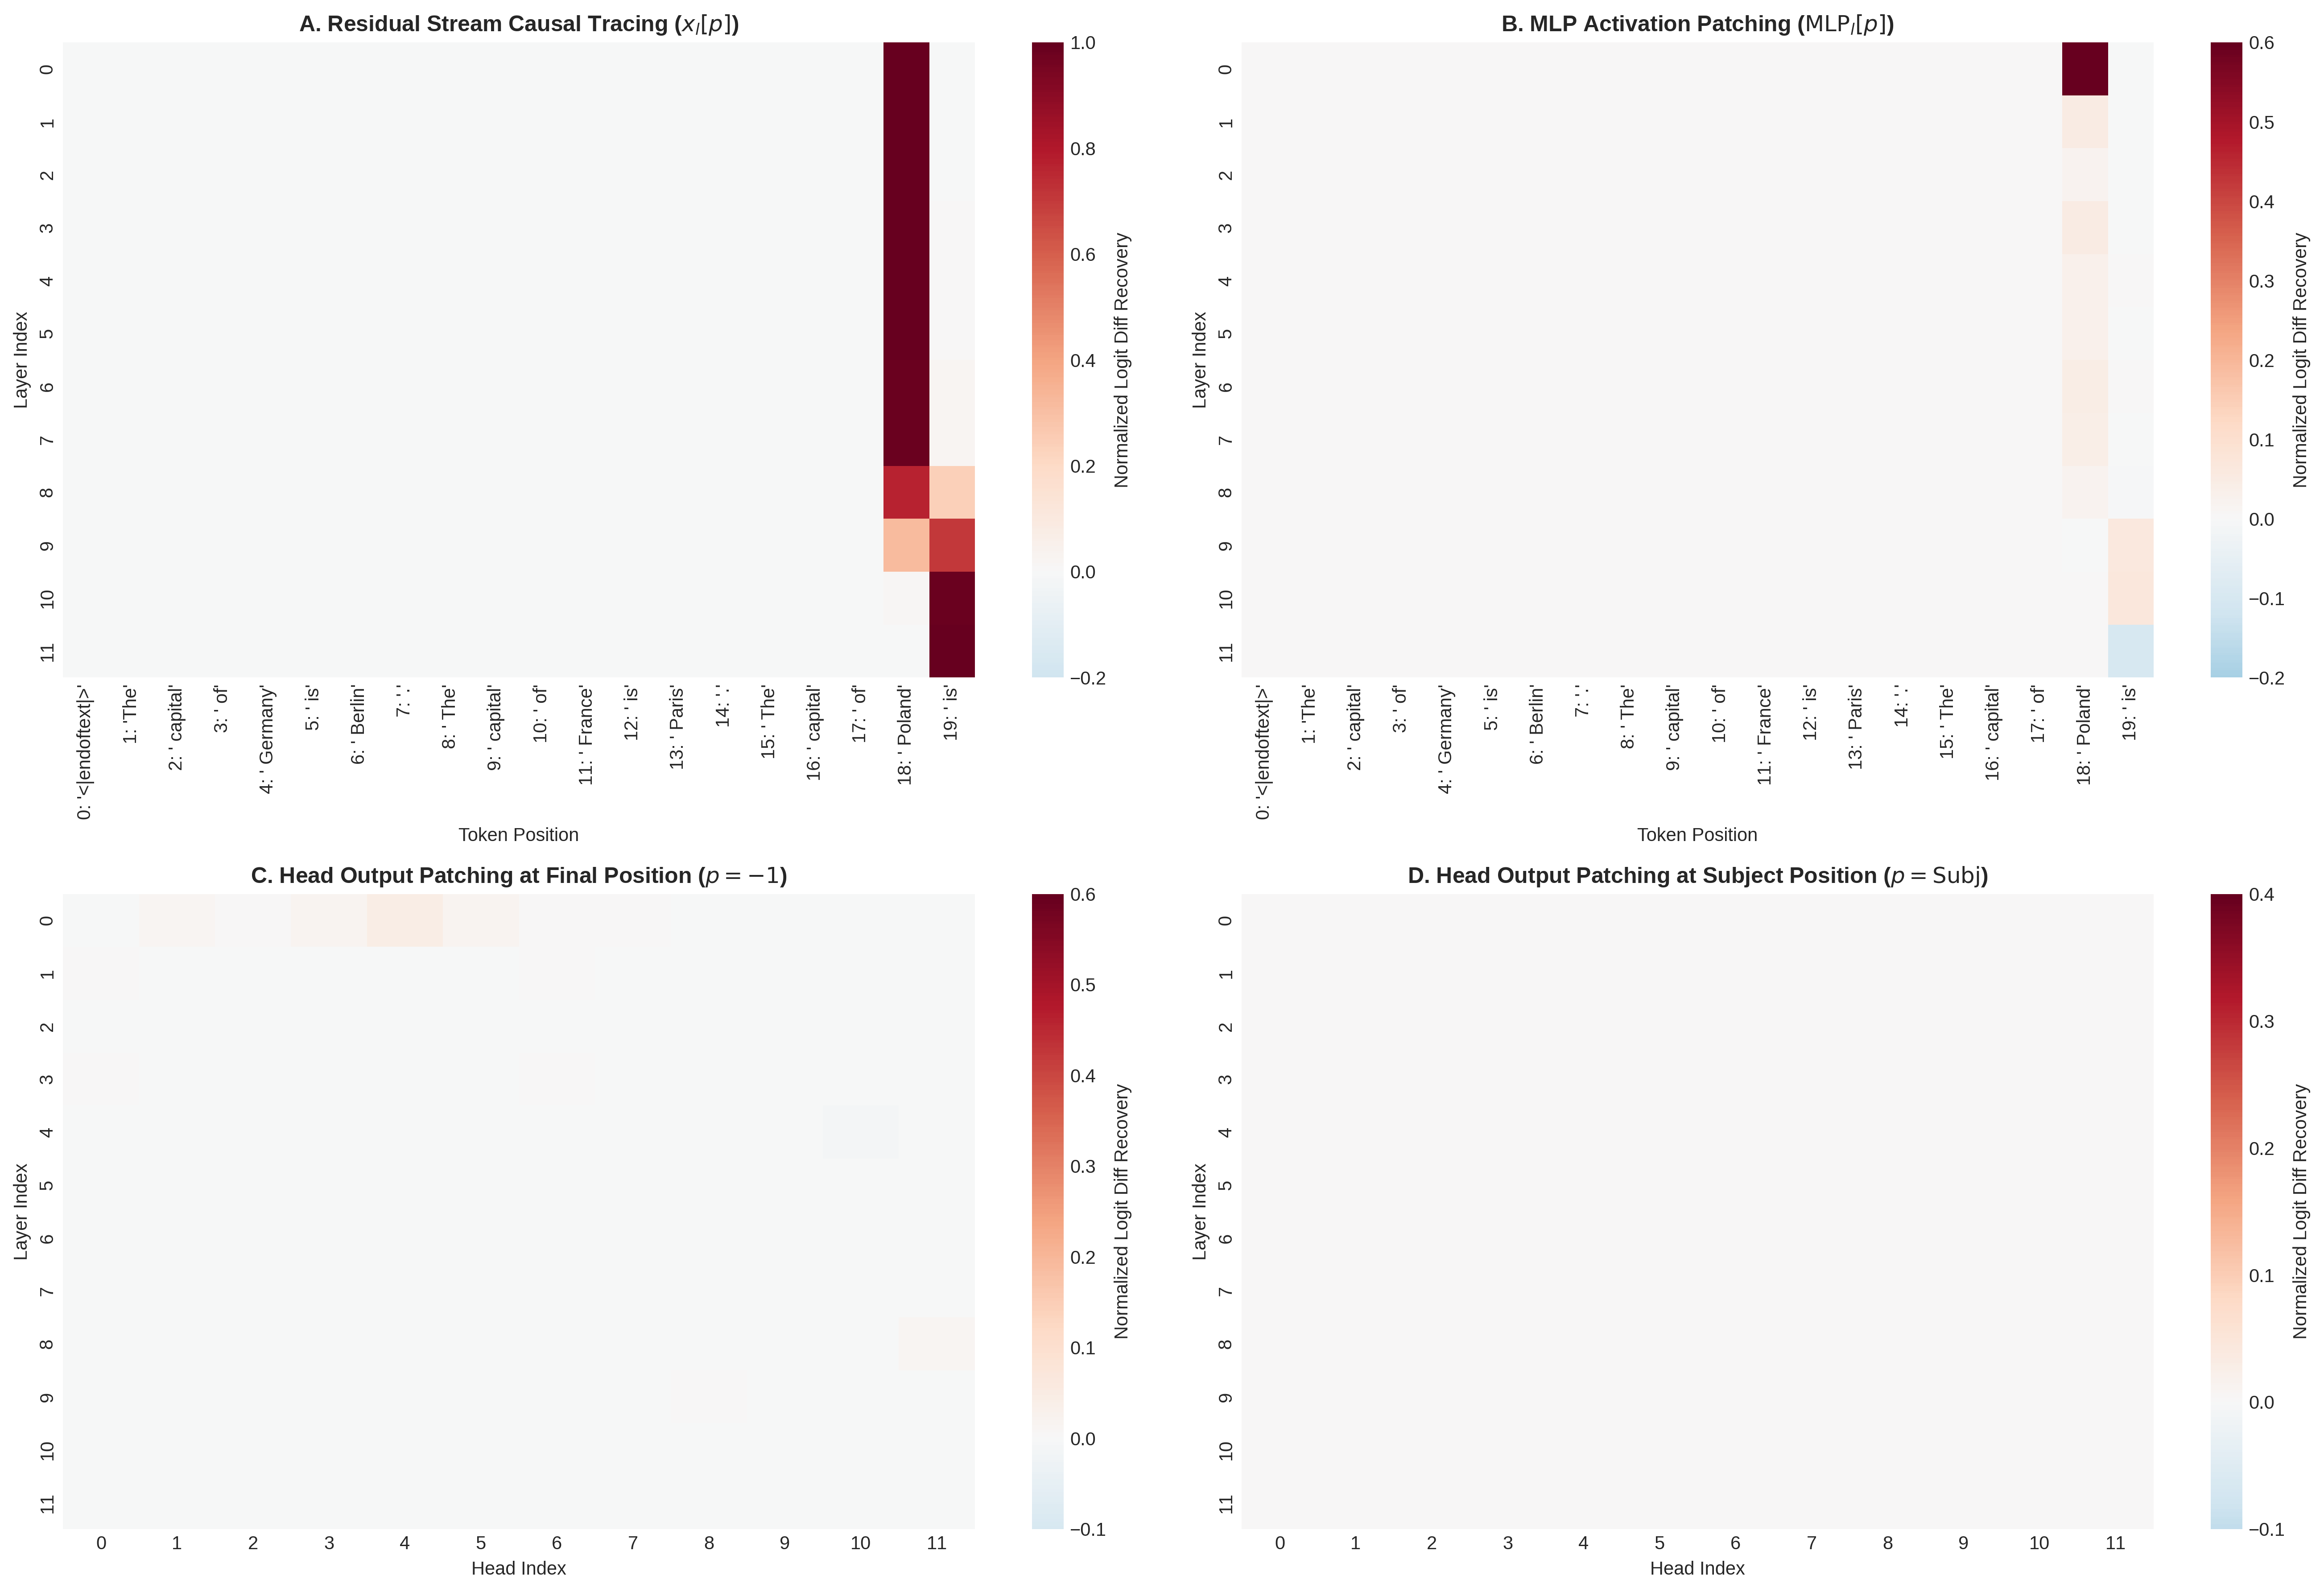


TOP 8 CAUSAL DIRECT WRITING HEADS (Patched at Final Token Position)
+-----+-----------+---------+--------+---------------------+---------------------+
|     | Head ID   |   Layer |   Head |   Last Pos Recovery |   Subj Pos Recovery |
|-----+-----------+---------+--------+---------------------+---------------------|
|   4 | L0H4      |       0 |      4 |              0.0468 |              0.0000 |
|   3 | L0H3      |       0 |      3 |              0.0201 |              0.0000 |
|   5 | L0H5      |       0 |      5 |              0.0150 |              0.0000 |
|   1 | L0H1      |       0 |      1 |              0.0132 |              0.0000 |
| 107 | L8H11     |       8 |     11 |              0.0111 |              0.0000 |
| 116 | L9H8      |       9 |      8 |              0.0058 |              0.0000 |
|   6 | L0H6      |       0 |      6 |              0.0046 |              0.0000 |
|   2 | L0H2      |       0 |      2 |              0.0034 |              0.0000 |
+-----+-----------

In [ ]:
# Cell: Day 3 - Activation Patching & Causal Circuit Discovery
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tabulate import tabulate
from transformer_lens import HookedTransformer

# 1. Setup & Load Artifacts
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Executing Day 3 Causal Tracing on: {device.upper()}")

model = HookedTransformer.from_pretrained(
    "gpt2-small",
    center_unembed=True,
    center_writing_weights=True,
    fold_ln=True,
    device=device
)
model.set_use_attn_result(True)

data = torch.load("day1_baseline_data.pt", weights_only=False)
clean_prompts = data["clean_prompts"]
corr_prompts = data["corr_prompts"]
clean_tok_ids = data["clean_tok_ids"].to(device)
corr_tok_ids = data["corr_tok_ids"].to(device)

n_prompts = len(clean_prompts)
seq_len = data["seq_len"]

# 2. Compute Baseline Clean and Corrupted Logit Differences
with torch.no_grad():
    clean_logits, clean_cache = model.run_with_cache(clean_prompts)
    corr_logits, corr_cache = model.run_with_cache(corr_prompts)

def get_ld(logits):
    final_l = logits[:, -1, :]
    c = final_l.gather(dim=-1, index=clean_tok_ids.unsqueeze(-1)).squeeze(-1)
    d = final_l.gather(dim=-1, index=corr_tok_ids.unsqueeze(-1)).squeeze(-1)
    return (c - d).mean().item()

clean_baseline_ld = get_ld(clean_logits)
corr_baseline_ld = get_ld(corr_logits)
baseline_gap = clean_baseline_ld - corr_baseline_ld

print(f"Clean Baseline LD:     +{clean_baseline_ld:.4f}")
print(f"Corrupted Baseline LD: {corr_baseline_ld:.4f}")
print(f"Total Logit Gap:       +{baseline_gap:.4f}")

# Extract sample token strings for x-axis labeling
sample_tokens = [model.to_string(tok) for tok in model.to_tokens(clean_prompts[0])[0]]

# 3. Residual Stream Activation Patching: (Layer x Position)
print("\n[1/3] Sweeping Residual Stream Activation Patching...")
resid_patch_matrix = np.zeros((model.cfg.n_layers, seq_len))

for l in range(model.cfg.n_layers):
    hook_name = f"blocks.{l}.hook_resid_post"
    for pos in range(seq_len):
        def patch_resid_hook(corrupt_activation, hook):
            corrupt_activation[:, pos, :] = clean_cache[hook.name][:, pos, :]
            return corrupt_activation

        with torch.no_grad():
            patched_logits = model.run_with_hooks(
                corr_prompts,
                fwd_hooks=[(hook_name, patch_resid_hook)]
            )

        p_ld = get_ld(patched_logits)
        recovery = (p_ld - corr_baseline_ld) / baseline_gap
        resid_patch_matrix[l, pos] = recovery

# 4. Attention Head Activation Patching: (Layer x Head at Target Position)
print("[2/3] Sweeping Attention Head Activation Patching...")
head_patch_matrix_last_pos = np.zeros((model.cfg.n_layers, model.cfg.n_heads))
head_patch_matrix_subj_pos = np.zeros((model.cfg.n_layers, model.cfg.n_heads))

# Subject position is token index 17 in our isomorphic 19-token prompts
subj_pos = 17
last_pos = 18

for l in range(model.cfg.n_layers):
    hook_name = f"blocks.{l}.attn.hook_result"
    for h in range(model.cfg.n_heads):
        # Patching at final token position (Direct Writing Heads)
        def patch_head_last(corrupt_activation, hook):
            corrupt_activation[:, last_pos, h, :] = clean_cache[hook.name][:, last_pos, h, :]
            return corrupt_activation

        with torch.no_grad():
            patched_logits_last = model.run_with_hooks(
                corr_prompts,
                fwd_hooks=[(hook_name, patch_head_last)]
            )
        rec_last = (get_ld(patched_logits_last) - corr_baseline_ld) / baseline_gap
        head_patch_matrix_last_pos[l, h] = rec_last

        # Patching at subject token position (Information Routing Heads)
        def patch_head_subj(corrupt_activation, hook):
            corrupt_activation[:, subj_pos, h, :] = clean_cache[hook.name][:, subj_pos, h, :]
            return corrupt_activation

        with torch.no_grad():
            patched_logits_subj = model.run_with_hooks(
                corr_prompts,
                fwd_hooks=[(hook_name, patch_head_subj)]
            )
        rec_subj = (get_ld(patched_logits_subj) - corr_baseline_ld) / baseline_gap
        head_patch_matrix_subj_pos[l, h] = rec_subj

# 5. MLP Activation Patching: (Layer x Position)
print("[3/3] Sweeping MLP Activation Patching...")
mlp_patch_matrix = np.zeros((model.cfg.n_layers, seq_len))

for l in range(model.cfg.n_layers):
    hook_name = f"blocks.{l}.hook_mlp_out"
    for pos in range(seq_len):
        def patch_mlp_hook(corrupt_activation, hook):
            corrupt_activation[:, pos, :] = clean_cache[hook.name][:, pos, :]
            return corrupt_activation

        with torch.no_grad():
            patched_logits = model.run_with_hooks(
                corr_prompts,
                fwd_hooks=[(hook_name, patch_mlp_hook)]
            )
        rec_mlp = (get_ld(patched_logits) - corr_baseline_ld) / baseline_gap
        mlp_patch_matrix[l, pos] = rec_mlp

# 6. Generate Publication Figure 2 (Causal Tracing Multi-Panel)
plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")
fig, axes = plt.subplots(2, 2, figsize=(18, 12), dpi=300)

clean_token_labels = [f"{i}: {repr(t)}" for i, t in enumerate(sample_tokens)]

# Panel A: Residual Stream Causal Tracing
sns.heatmap(
    resid_patch_matrix,
    cmap="RdBu_r",
    center=0,
    vmin=-0.2,
    vmax=1.0,
    xticklabels=clean_token_labels,
    yticklabels=list(range(model.cfg.n_layers)),
    cbar_kws={'label': r'Normalized Logit Diff Recovery'},
    ax=axes[0, 0]
)
axes[0, 0].set_title(r"A. Residual Stream Causal Tracing ($x_l[p]$)", fontsize=12, fontweight="bold")
axes[0, 0].set_xlabel("Token Position", fontsize=10)
axes[0, 0].set_ylabel("Layer Index", fontsize=10)
axes[0, 0].tick_params(axis='x', rotation=90)

# Panel B: MLP Causal Tracing
sns.heatmap(
    mlp_patch_matrix,
    cmap="RdBu_r",
    center=0,
    vmin=-0.2,
    vmax=0.6,
    xticklabels=clean_token_labels,
    yticklabels=list(range(model.cfg.n_layers)),
    cbar_kws={'label': r'Normalized Logit Diff Recovery'},
    ax=axes[0, 1]
)
axes[0, 1].set_title(r"B. MLP Activation Patching ($\text{MLP}_l[p]$)", fontsize=12, fontweight="bold")
axes[0, 1].set_xlabel("Token Position", fontsize=10)
axes[0, 1].set_ylabel("Layer Index", fontsize=10)
axes[0, 1].tick_params(axis='x', rotation=90)

# Panel C: Attention Heads Patched at Final Token Position (Direct Writers)
sns.heatmap(
    head_patch_matrix_last_pos,
    cmap="RdBu_r",
    center=0,
    vmin=-0.1,
    vmax=0.6,
    yticklabels=list(range(model.cfg.n_layers)),
    cbar_kws={'label': r'Normalized Logit Diff Recovery'},
    ax=axes[1, 0]
)
axes[1, 0].set_title(r"C. Head Output Patching at Final Position ($p=-1$)", fontsize=12, fontweight="bold")
axes[1, 0].set_xlabel("Head Index", fontsize=10)
axes[1, 0].set_ylabel("Layer Index", fontsize=10)

# Panel D: Attention Heads Patched at Subject Position (Information Movers)
sns.heatmap(
    head_patch_matrix_subj_pos,
    cmap="RdBu_r",
    center=0,
    vmin=-0.1,
    vmax=0.4,
    yticklabels=list(range(model.cfg.n_layers)),
    cbar_kws={'label': r'Normalized Logit Diff Recovery'},
    ax=axes[1, 1]
)
axes[1, 1].set_title(r"D. Head Output Patching at Subject Position ($p=\text{Subj}$)", fontsize=12, fontweight="bold")
axes[1, 1].set_xlabel("Head Index", fontsize=10)
axes[1, 1].set_ylabel("Layer Index", fontsize=10)

plt.tight_layout()
plt.savefig("figure2_activation_patching.png", dpi=300, bbox_inches="tight")
plt.savefig("figure2_activation_patching.pdf", bbox_inches="tight")
plt.show()

# 7. Print Ranked Causal Circuits
head_causal_records = []
for l in range(model.cfg.n_layers):
    for h in range(model.cfg.n_heads):
        head_causal_records.append({
            "Head ID": f"L{l}H{h}",
            "Layer": l,
            "Head": h,
            "Last_Pos_Recovery": head_patch_matrix_last_pos[l, h],
            "Subj_Pos_Recovery": head_patch_matrix_subj_pos[l, h]
        })

df_causal_heads = pd.DataFrame(head_causal_records)

print("\n" + "="*65)
print("TOP 8 CAUSAL DIRECT WRITING HEADS (Patched at Final Token Position)")
print("="*65)
print(tabulate(
    df_causal_heads.sort_values(by="Last_Pos_Recovery", ascending=False).head(8),
    headers=["Head ID", "Layer", "Head", "Last Pos Recovery", "Subj Pos Recovery"],
    tablefmt="psql",
    floatfmt=".4f"
))

print("\n" + "="*65)
print("TOP 8 CAUSAL INFORMATION MOVER / RELATION HEADS (Patched at Subject)")
print("="*65)
print(tabulate(
    df_causal_heads.sort_values(by="Subj_Pos_Recovery", ascending=False).head(8),
    headers=["Head ID", "Layer", "Head", "Last Pos Recovery", "Subj Pos Recovery"],
    tablefmt="psql",
    floatfmt=".4f"
))

# 8. Save Day 3 Artifacts
torch.save({
    "resid_patch_matrix": resid_patch_matrix,
    "mlp_patch_matrix": mlp_patch_matrix,
    "head_patch_matrix_last_pos": head_patch_matrix_last_pos,
    "head_patch_matrix_subj_pos": head_patch_matrix_subj_pos,
    "df_causal_heads": df_causal_heads
}, "day3_patching_data.pt")
print("\nDay 3 artifacts and Figure 2 (PNG/PDF) serialized successfully.")

Executing Day 4 Ablation Pipeline on: CUDA


/tmp/ipykernel_1194/3205425671.py:15: DeprecationWarning: HookedTransformer.from_pretrained is deprecated and will be removed in a future major release. Use TransformerBridge.boot_transformers(...) instead, then call enable_compatibility_mode() for HookedTransformer-equivalent numerics. See docs/source/content/migrating_to_v3.md.
  model = HookedTransformer.from_pretrained(


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loaded pretrained model gpt2-small into HookedTransformer
Baseline Clean Logit Diff: +10.4602 | Accuracy: 100.00%


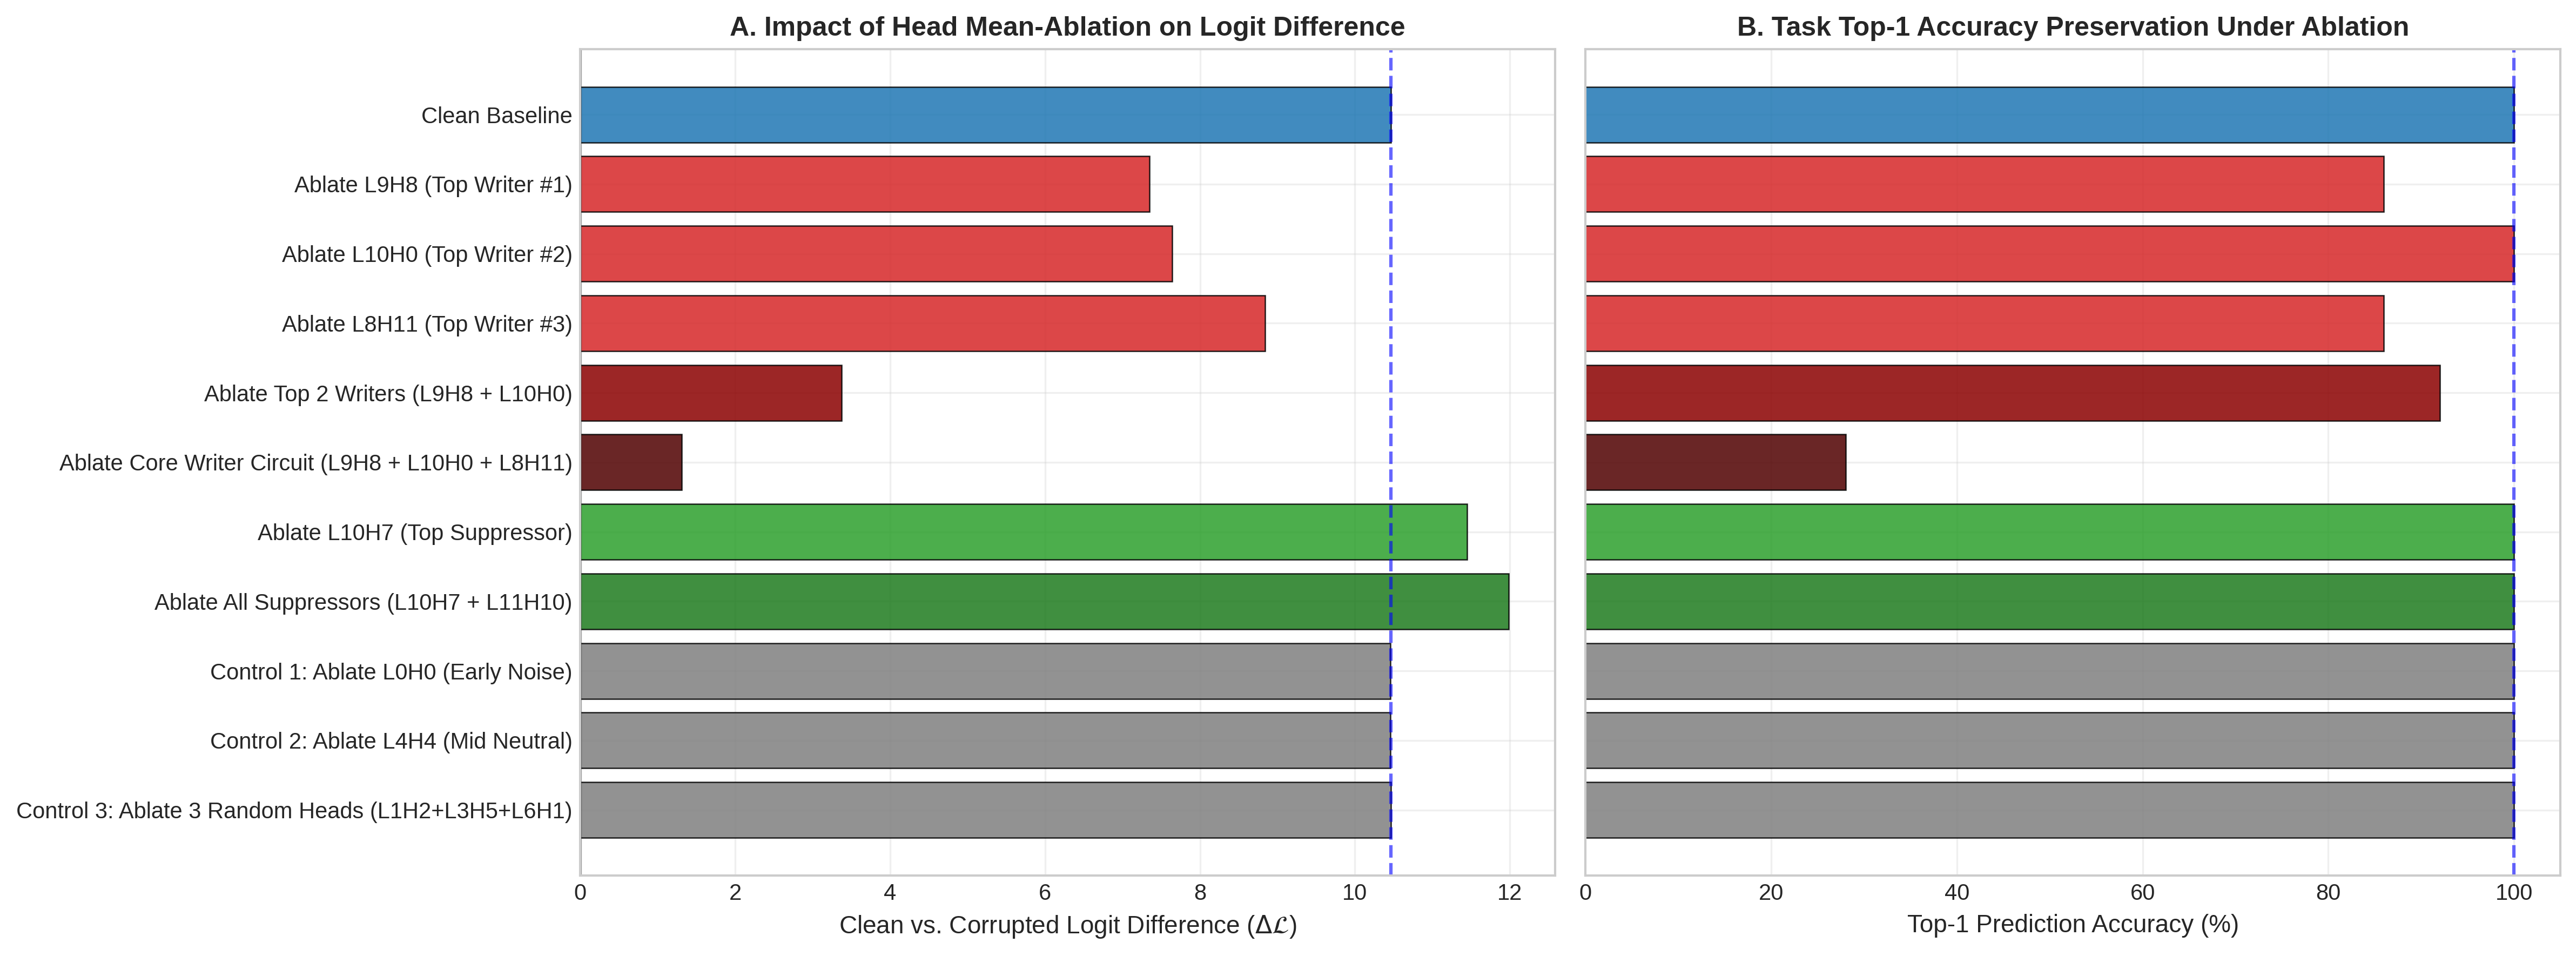


CIRCUIT ABLATION EXPERIMENTAL BATTERY (DAY 4)
+----+---------------------------------------------------+--------------------+-----------------------+----------------------+---------------------+
|    | Experiment Condition                              |   Logit Difference |   Logit Diff Drop (%) |   Top-1 Accuracy (%) |   Num Heads Ablated |
|----+---------------------------------------------------+--------------------+-----------------------+----------------------+---------------------|
|  0 | Clean Baseline                                    |              10.46 |                  0.00 |               100.00 |                   0 |
|  1 | Ablate L9H8 (Top Writer #1)                       |               7.35 |                 29.74 |                86.00 |                   1 |
|  2 | Ablate L10H0 (Top Writer #2)                      |               7.64 |                 26.96 |               100.00 |                   1 |
|  3 | Ablate L8H11 (Top Writer #3)                      | 

In [ ]:
# Cell: Day 4 - Circuit Isolation & Knockout Ablation Pipeline
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tabulate import tabulate
from functools import partial
from transformer_lens import HookedTransformer

# 1. Environment & Model Initialization
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Executing Day 4 Ablation Pipeline on: {device.upper()}")

model = HookedTransformer.from_pretrained(
    "gpt2-small",
    center_unembed=True,
    center_writing_weights=True,
    fold_ln=True,
    device=device
)
model.set_use_attn_result(True)

# 2. Load Dataset Artifacts
data = torch.load("day1_baseline_data.pt", weights_only=False)
clean_prompts = data["clean_prompts"]
clean_tok_ids = data["clean_tok_ids"].to(device)
corr_tok_ids = data["corr_tok_ids"].to(device)
n_prompts = len(clean_prompts)

# 3. Cache Mean Head Activations Across All Layers and Positions
with torch.no_grad():
    clean_logits, clean_cache = model.run_with_cache(clean_prompts)

# Compute mean activations for hook_result: shape [n_layers, seq_len, n_heads, d_model]
mean_head_activations = {}
for l in range(model.cfg.n_layers):
    hook_name = f"blocks.{l}.attn.hook_result"
    # Average across the batch dimension: [seq_len, n_heads, d_model]
    mean_head_activations[l] = clean_cache[hook_name].mean(dim=0)

# Baseline Evaluation Function
def evaluate_model_performance(logits):
    final_l = logits[:, -1, :]
    c_logits = final_l.gather(dim=-1, index=clean_tok_ids.unsqueeze(-1)).squeeze(-1)
    d_logits = final_l.gather(dim=-1, index=corr_tok_ids.unsqueeze(-1)).squeeze(-1)

    ld = (c_logits - d_logits).mean().item()
    preds = final_l.argmax(dim=-1)
    acc = (preds == clean_tok_ids).float().mean().item() * 100
    return ld, acc

clean_baseline_ld, clean_baseline_acc = evaluate_model_performance(clean_logits)
print(f"Baseline Clean Logit Diff: +{clean_baseline_ld:.4f} | Accuracy: {clean_baseline_acc:.2f}%")

# 4. Multi-Head Mean-Ablation Hook Constructor
def make_ablation_hook(target_heads, mean_acts_dict):
    """
    target_heads: list of tuples [(layer, head_idx), ...]
    mean_acts_dict: dictionary of precomputed mean tensors per layer
    """
    layer_to_heads = {}
    for l, h in target_heads:
        if l not in layer_to_heads:
            layer_to_heads[l] = []
        layer_to_heads[l].append(h)

    hook_list = []
    for l, heads in layer_to_heads.items():
        hook_name = f"blocks.{l}.attn.hook_result"

        def hook_fn(activation, hook, layer_idx=l, head_indices=heads):
            # activation shape: [batch, seq_len, n_heads, d_model]
            for h in head_indices:
                activation[:, :, h, :] = mean_acts_dict[layer_idx][:, h, :].unsqueeze(0)
            return activation

        hook_list.append((hook_name, hook_fn))
    return hook_list

# 5. Define Experimental Ablation Conditions
experiments = [
    {"name": "Clean Baseline", "heads": []},

    # Individual Top Writing Heads
    {"name": "Ablate L9H8 (Top Writer #1)", "heads": [(9, 8)]},
    {"name": "Ablate L10H0 (Top Writer #2)", "heads": [(10, 0)]},
    {"name": "Ablate L8H11 (Top Writer #3)", "heads": [(8, 11)]},

    # Joint Writing Circuit Ablation
    {"name": "Ablate Top 2 Writers (L9H8 + L10H0)", "heads": [(9, 8), (10, 0)]},
    {"name": "Ablate Core Writer Circuit (L9H8 + L10H0 + L8H11)", "heads": [(9, 8), (10, 0), (8, 11)]},

    # Suppressor / Negative Heads
    {"name": "Ablate L10H7 (Top Suppressor)", "heads": [(10, 7)]},
    {"name": "Ablate All Suppressors (L10H7 + L11H10)", "heads": [(10, 7), (11, 10)]},

    # Control Experiments (Random non-circuit heads)
    {"name": "Control 1: Ablate L0H0 (Early Noise)", "heads": [(0, 0)]},
    {"name": "Control 2: Ablate L4H4 (Mid Neutral)", "heads": [(4, 4)]},
    {"name": "Control 3: Ablate 3 Random Heads (L1H2+L3H5+L6H1)", "heads": [(1, 2), (3, 5), (6, 1)]}
]

# 6. Execute Ablation Battery
ablation_results = []

for exp in experiments:
    name = exp["name"]
    heads = exp["heads"]

    if len(heads) == 0:
        ld, acc = clean_baseline_ld, clean_baseline_acc
    else:
        hooks = make_ablation_hook(heads, mean_head_activations)
        with torch.no_grad():
            ablated_logits = model.run_with_hooks(
                clean_prompts,
                fwd_hooks=hooks
            )
        ld, acc = evaluate_model_performance(ablated_logits)

    drop_pct = ((clean_baseline_ld - ld) / clean_baseline_ld) * 100
    ablation_results.append({
        "Experiment Condition": name,
        "Logit Difference": ld,
        "Logit Diff Drop (%)": drop_pct,
        "Top-1 Accuracy (%)": acc,
        "Num Heads Ablated": len(heads)
    })

df_ablation = pd.DataFrame(ablation_results)

# 7. Generate Figure 3 (Publication Quality)
plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), dpi=300)

# Color mapping: Clean (Blue), Writers (Red), Suppressors (Green), Controls (Gray)
palette = [
    "#1f77b4",
    "#d62728", "#d62728", "#d62728", "#8b0000", "#500000",
    "#2ca02c", "#1e7b1e",
    "#7f7f7f", "#7f7f7f", "#7f7f7f"
]

y_labels = df_ablation["Experiment Condition"]
y_pos = np.arange(len(y_labels))

# Panel A: Mean Logit Difference
ax1.barh(y_pos, df_ablation["Logit Difference"], color=palette, alpha=0.85, edgecolor="black", linewidth=0.6)
ax1.axvline(clean_baseline_ld, color="blue", linestyle="--", alpha=0.6, label="Clean Baseline")
ax1.axvline(0, color="black", linestyle="-", alpha=0.4)
ax1.set_yticks(y_pos)
ax1.set_yticklabels(y_labels, fontsize=10)
ax1.invert_yaxis()
ax1.set_xlabel(r"Clean vs. Corrupted Logit Difference ($\Delta \mathcal{L}$)", fontsize=11)
ax1.set_title(r"A. Impact of Head Mean-Ablation on Logit Difference", fontsize=12, fontweight="bold")
ax1.grid(True, alpha=0.3)

# Panel B: Top-1 Task Accuracy
ax2.barh(y_pos, df_ablation["Top-1 Accuracy (%)"], color=palette, alpha=0.85, edgecolor="black", linewidth=0.6)
ax2.axvline(100.0, color="blue", linestyle="--", alpha=0.6)
ax2.set_yticks(y_pos)
ax2.set_yticklabels([]) # Hide duplicate labels
ax2.invert_yaxis()
ax2.set_xlim(0, 105)
ax2.set_xlabel("Top-1 Prediction Accuracy (%)", fontsize=11)
ax2.set_title("B. Task Top-1 Accuracy Preservation Under Ablation", fontsize=12, fontweight="bold")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("figure3_ablation_experiments.png", dpi=300, bbox_inches="tight")
plt.savefig("figure3_ablation_experiments.pdf", bbox_inches="tight")
plt.show()

# 8. Print Formatted Table of Empirical Ablation Results
print("\n" + "="*80)
print("CIRCUIT ABLATION EXPERIMENTAL BATTERY (DAY 4)")
print("="*80)
print(tabulate(df_ablation, headers="keys", tablefmt="psql", floatfmt=".2f"))

# 9. Save Day 4 Artifacts
torch.save({
    "df_ablation": df_ablation,
    "clean_baseline_ld": clean_baseline_ld,
    "clean_baseline_acc": clean_baseline_acc
}, "day4_ablation_data.pt")
print("\nDay 4 artifacts and Figure 3 (PNG/PDF) saved successfully.")